<a href="https://colab.research.google.com/github/harshsu7/Linear-Regression/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression – 50 Startups Dataset (Teachable Notebook)

## Problem Statement
We want to predict **Profit** of a startup based on multiple factors such as:
- R&D Spend
- Administration Spend
- Marketing Spend
- State (categorical)

**Type of ML Problem:** Regression (continuous output)


## Step 1: Import Required Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 2: Load the Dataset
Make sure `50_Startups.csv` is in the same folder as this notebook.

In [2]:

df = pd.read_csv(r'/content/50_Startups.csv')
df.head()


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Step 3: Basic Exploratory Data Analysis (EDA)

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [4]:

df.describe()


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


### Checking for Missing Values

In [5]:

df.isnull().sum()


,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


### Correlation Heatmap (Numerical Features)

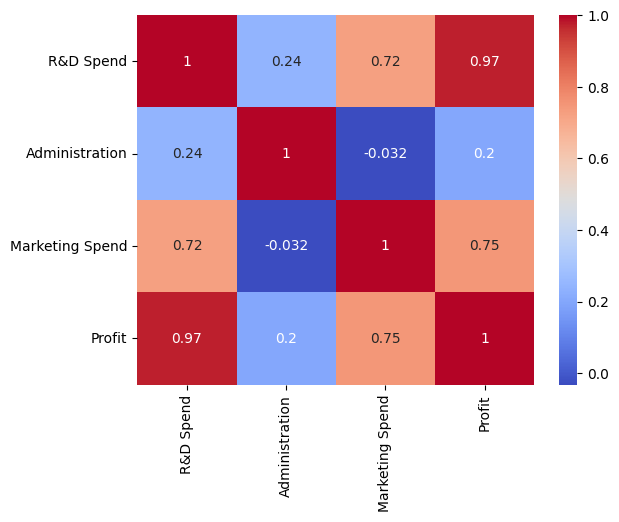

In [6]:

sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()


## Step 4: Feature and Target Separation
- **Target (y):** Profit
- **Features (X):** All other columns

In [7]:

X = df.drop('Profit', axis=1)
y = df['Profit']


## Step 5: Encoding Categorical Variable (State)
We use One Hot Encoding because `State` is a nominal categorical feature.

In [8]:

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()


,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False


## Step 6: Train–Test Split

In [9]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


## Step 7: Feature Scaling
Scaling is important because features have different units and ranges.

In [10]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 8: Model Training – Multiple Linear Regression

In [11]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

### Model Coefficients
Each coefficient shows how much the Profit changes with a unit change in the feature.

In [12]:

coeff_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_
})
coeff_df


,Feature,Coefficient
0,R&D Spend,38102.269270
1,Administration,-1864.754300
2,Marketing Spend,3386.175807
3,State_Florida,447.775725
4,State_New York,3.272891


## Step 9: Predictions

In [13]:

y_pred = model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Predicted Profit': y_pred
})
comparison


,Actual Profit,Predicted Profit
0,134307.35,126362.879083
1,81005.76,84608.453836
2,99937.59,99677.494252
3,64926.08,46357.460686
4,125370.37,128750.482885
5,35673.41,50912.417419
6,105733.54,109741.350327
7,107404.34,100643.242816
8,97427.84,97599.275746
9,122776.86,113097.425244


### Predicting Profit for a New Startup

In [14]:

# Example startup
new_startup = pd.DataFrame([{
    'R&D Spend': 160000,
    'Administration': 120000,
    'Marketing Spend': 300000,
    'State_Florida': 0,
    'State_New York': 1
}])

new_startup_scaled = scaler.transform(new_startup)
model.predict(new_startup_scaled)


array([183637.9245517])

## Step 10: Model Evaluation (Regression Metrics)

In [15]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2


(6961.477813275558, np.float64(9055.957323497809), 0.8987266414319838)

## Final Notes
- Multiple Linear Regression predicts **continuous values**
- Encoding and scaling are essential steps here
- Evaluation is based on error metrics, not accuracy
- This dataset clearly shows how multiple factors influence profit